# IPL 2026 Winner Prediction

This notebook uses the IPL dataset in this folder to build a simple, explainable forecast for the 2026 season.

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', context='notebook')

## 1. Load the dataset

The dataset is ball-by-ball IPL data, so we first convert it into match-level records before making a season forecast.

In [20]:
df = pd.read_csv('IPL.csv', low_memory=False)
print('Raw shape:', df.shape)
df.info()

duplicate_rows = df[df.duplicated()].copy()
print('Duplicate rows found:', duplicate_rows.shape[0])
if not duplicate_rows.empty:
    display(duplicate_rows.head())

df = df.drop_duplicates().copy()
print('Shape after dropping duplicates:', df.shape)
print('Remaining duplicates:', df.duplicated().sum())

display(df.describe(include='all').transpose())
display(df.head())
display(df[['season', 'match_won_by']].head())

Raw shape: (283678, 65)
<class 'pandas.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  str    
 3   match_type         283678 non-null  str    
 4   event_name         283678 non-null  str    
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  str    
 7   bowling_team       283678 non-null  str    
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  str    
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  st

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,283678.0,NaN,NaN,NaN,141838.5,81890.929169,0.0,70919.25,141838.5,212757.75,283677.0
match_id,283678.0,NaN,NaN,NaN,953568.39462,386509.131505,335982.0,548359.0,1082612.0,1304066.0,1529267.0
date,283678,905,2020-10-18,520,NaN,NaN,NaN,NaN,NaN,NaN,NaN
match_type,283678,1,T20,283678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
event_name,283678,1,Indian Premier League,283678,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
batter_balls,283678.0,NaN,NaN,NaN,13.993813,11.815576,0.0,5.0,11.0,20.0,73.0
bowler_wicket,283678.0,NaN,NaN,NaN,0.04553,0.208465,0.0,0.0,0.0,0.0,1.0
batting_partners,283678,5235,"('AB de Villiers', 'V Kohli')",2059,NaN,NaN,NaN,NaN,NaN,NaN,NaN
next_batter,13593,679,MS Dhoni,242,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,ball_no,batter,bat_pos,runs_batter,balls_faced,bowler,valid_ball,runs_extras,runs_total,runs_bowler,runs_not_boundary,extra_type,non_striker,non_striker_pos,wicket_kind,player_out,fielders,runs_target,review_batter,team_reviewed,review_decision,umpire,umpires_call,player_of_match,match_won_by,win_outcome,toss_winner,toss_decision,venue,city,day,month,year,season,gender,team_type,superover_winner,result_type,method,balls_per_over,overs,event_match_no,stage,match_number,team_runs,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,0.1,SC Ganguly,1,0,1,P Kumar,1,1,1,0,False,legbyes,BB McCullum,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,1,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,0.2,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,1,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,BB McCullum,2,0,0,P Kumar,0,1,1,1,False,wides,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,0.3,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,0.4,BB McCullum,2,0,1,P Kumar,1,0,0,0,False,NaN,SC Ganguly,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,BB McCullum,Kolkata Knight Riders,140 runs,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,18,4,2008,2007/08,male,club,NaN,NaN,NaN,6,20,1,Unknown,Unknown,2,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


,season,match_won_by
0,2007/08,Kolkata Knight Riders
1,2007/08,Kolkata Knight Riders
2,2007/08,Kolkata Knight Riders
3,2007/08,Kolkata Knight Riders
4,2007/08,Kolkata Knight Riders


## 2. Missing Values Strategy

I am not using a blanket `dropna()` here because this dataset is large and sparse in several columns, and dropping every incomplete row would discard a lot of usable match context. For the analysis visuals, I use **median** imputation for numeric columns because IPL ball-by-ball metrics are skewed and outlier-heavy, and I use **mode** imputation for categorical columns because those fields are label-like. That keeps the dataset intact while still giving me a clean table for summaries and plots.

In [17]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]
display(missing_summary.to_frame('missing_count'))

analysis_df = df.copy()
numeric_cols = analysis_df.select_dtypes(include=['number']).columns
for column in numeric_cols:
    if analysis_df[column].isna().any():
        analysis_df[column] = analysis_df[column].fillna(analysis_df[column].median())

categorical_cols = analysis_df.select_dtypes(include=['object', 'string']).columns
for column in categorical_cols:
    if analysis_df[column].isna().any():
        modes = analysis_df[column].mode(dropna=True)
        if not modes.empty:
            analysis_df[column] = analysis_df[column].fillna(modes.iloc[0])

,missing_count
power_surge_start,283678
team_reviewed,282771
review_batter,282771
review_decision,282771
umpire,282771
method,279788
superover_winner,279782
result_type,278954
fielders,273433
next_batter,270085


## 3. Visual Analysis

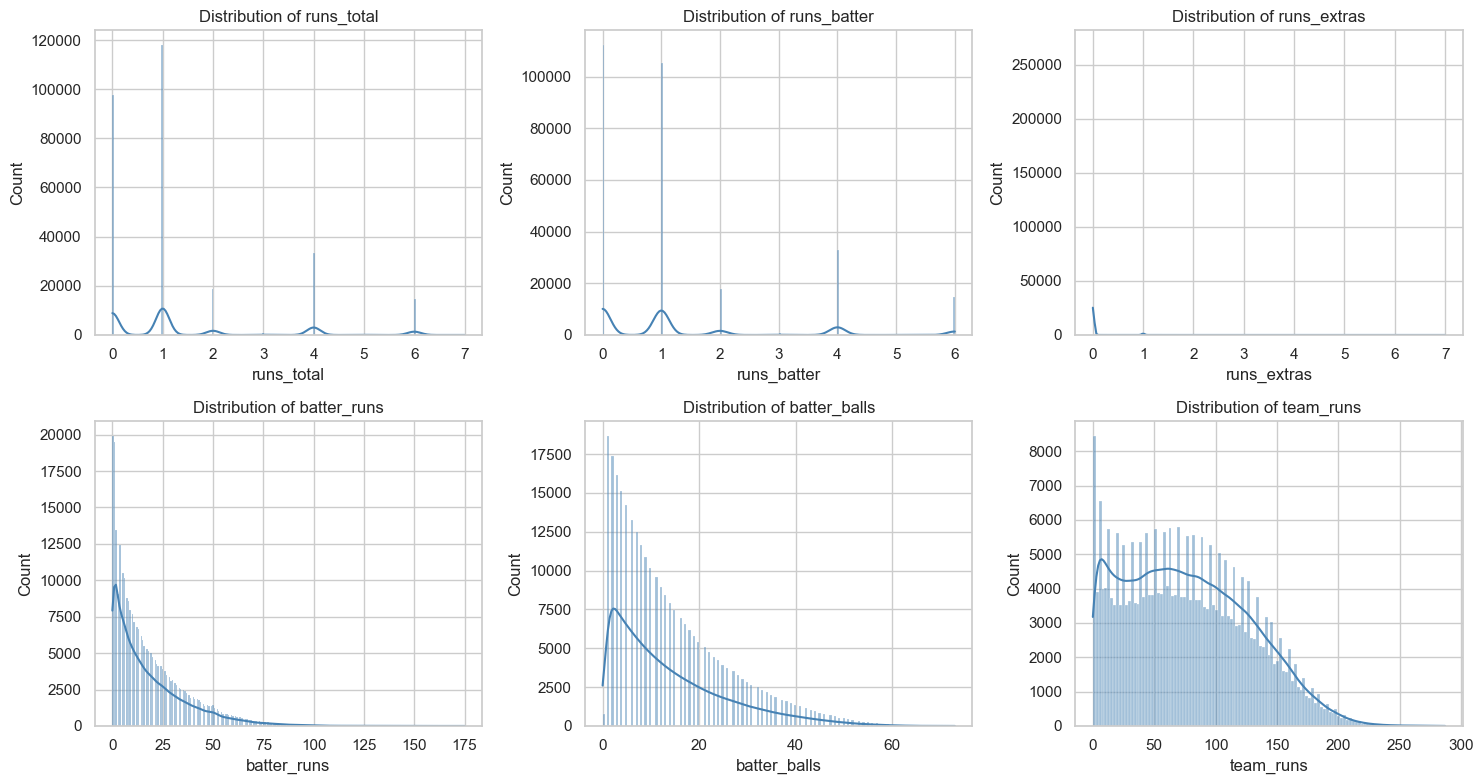

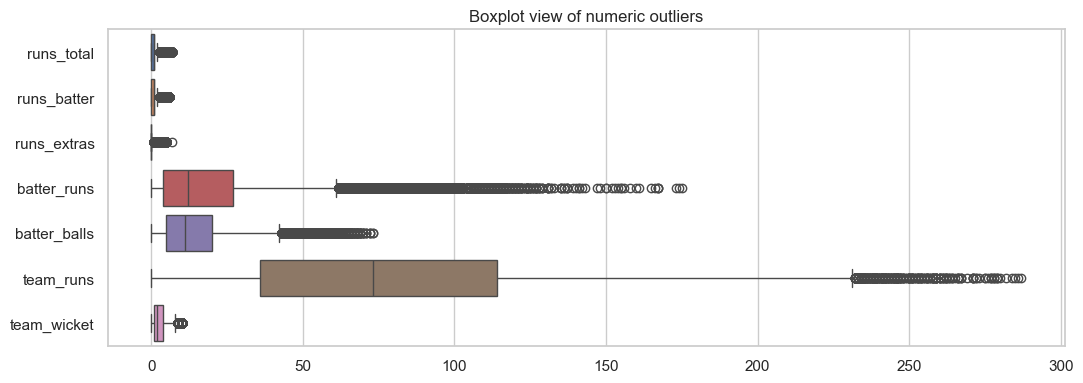

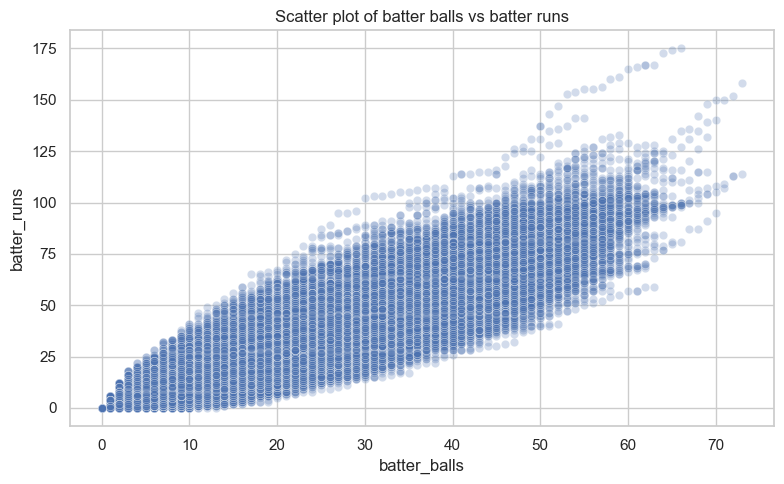

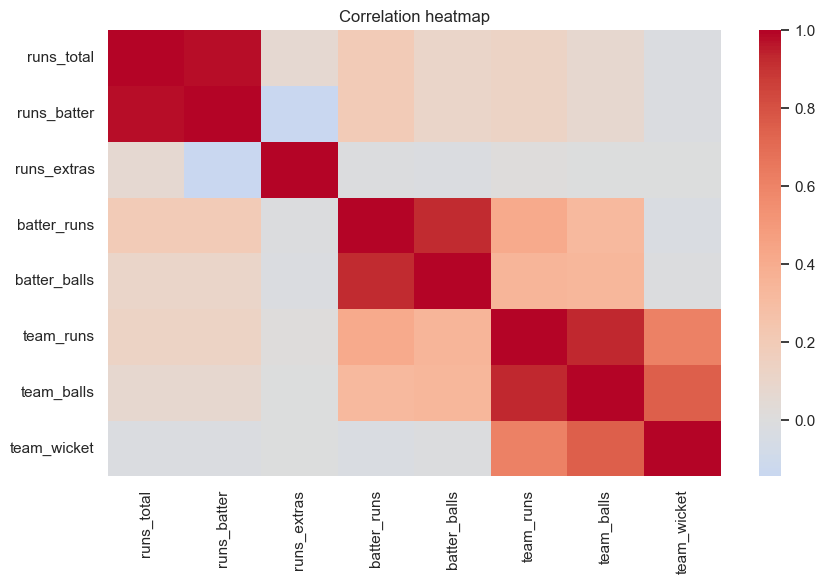

In [18]:
visual_columns = ['runs_total', 'runs_batter', 'runs_extras', 'batter_runs', 'batter_balls', 'team_runs', 'team_balls', 'team_wicket']
visual_df = analysis_df[visual_columns].copy()
visual_df = visual_df.fillna(visual_df.median(numeric_only=True))

hist_columns = ['runs_total', 'runs_batter', 'runs_extras', 'batter_runs', 'batter_balls', 'team_runs']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for axis, column in zip(axes.flat, hist_columns):
    sns.histplot(visual_df[column], kde=True, ax=axis, color='steelblue')
    axis.set_title(f'Distribution of {column}')
    axis.set_xlabel(column)
    axis.set_ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure(figsize=(11, 4))
sns.boxplot(data=visual_df[['runs_total', 'runs_batter', 'runs_extras', 'batter_runs', 'batter_balls', 'team_runs', 'team_wicket']], orient='h')
plt.title('Boxplot view of numeric outliers')
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=visual_df, x='batter_balls', y='batter_runs', alpha=0.25)
plt.title('Scatter plot of batter balls vs batter runs')
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))
sns.heatmap(visual_df.corr(numeric_only=True), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()

In [6]:
matches = df.drop_duplicates('match_id').copy()
matches['season'] = matches['season'].astype(str)
matches['season_order'] = matches['season'].map(lambda value: int(str(value).split('/')[0]))

print('Match-level shape:', matches.shape)
display(matches[['match_id', 'season', 'stage', 'match_won_by']].head())

finals = matches[matches['stage'].astype(str).str.lower().eq('final') & matches['match_won_by'].ne('Unknown')].copy()
finals = finals.sort_values('season_order')
display(finals[['season', 'match_won_by']].tail(12))

print('Latest season in the file:', matches['season'].max())
print('2026 matches in the file:', (matches['season'] == '2026').sum())

Match-level shape: (1193, 66)


,match_id,season,stage,match_won_by
0,335982,2007/08,Unknown,Kolkata Knight Riders
225,335983,2007/08,Unknown,Chennai Super Kings
473,335984,2007/08,Unknown,Delhi Daredevils
692,335985,2007/08,Unknown,Royal Challengers Bangalore
938,335986,2007/08,Unknown,Kolkata Knight Riders


,season,match_won_by
108605,2014,Kolkata Knight Riders
122256,2015,Mumbai Indians
136348,2016,Sunrisers Hyderabad
150212,2017,Mumbai Indians
164505,2018,Chennai Super Kings
178811,2019,Mumbai Indians
193382,2020/21,Mumbai Indians
207789,2021,Chennai Super Kings
225721,2022,Gujarat Titans
243601,2023,Chennai Super Kings


Latest season in the file: 2026
2026 matches in the file: 24


## 4. Simple forecasting idea

The prediction combines three signals:

- Current 2026 wins to date
- Historical championship count
- A small bonus for the most recent champion

This is intentionally simple and explainable, so it works well for a short presentation.

,wins_2026,titles,recent_champion_bonus,score
match_won_by,,,,
Royal Challengers Bengaluru,4.0,1.0,1,45.0
Rajasthan Royals,4.0,1.0,0,42.0
Punjab Kings,4.0,0.0,0,40.0
Chennai Super Kings,2.0,5.0,0,30.0
Gujarat Titans,2.0,1.0,0,22.0
Sunrisers Hyderabad,2.0,1.0,0,22.0
Delhi Capitals,2.0,0.0,0,20.0
Mumbai Indians,1.0,5.0,0,20.0
Lucknow Super Giants,2.0,0.0,0,20.0


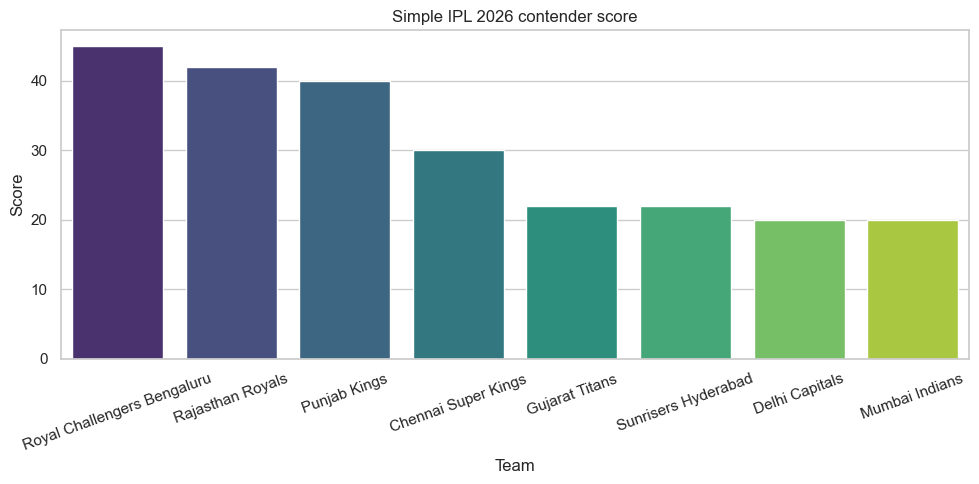

Predicted IPL 2026 winner: Royal Challengers Bengaluru


In [16]:
current_2026 = matches[matches['season'] == '2026'].copy()
current_wins = current_2026[current_2026['match_won_by'].ne('Unknown')]['match_won_by'].value_counts()
title_counts = finals['match_won_by'].value_counts()
latest_champion = finals.iloc[-1]['match_won_by'] if not finals.empty else ''

forecast = pd.DataFrame({'wins_2026': current_wins, 'titles': title_counts}).fillna(0)
forecast['recent_champion_bonus'] = (forecast.index == latest_champion).astype(int)
forecast['score'] = forecast['wins_2026'] * 10 + forecast['titles'] * 2 + forecast['recent_champion_bonus'] * 3
forecast = forecast.sort_values('score', ascending=False)

display(forecast.head(10))

top8 = forecast.head(8).reset_index()
plt.figure(figsize=(10, 5))
sns.barplot(data=top8, x='match_won_by', y='score', hue='match_won_by', palette='viridis', dodge=False, legend=False)
plt.title('Simple IPL 2026 contender score')
plt.xlabel('Team')
plt.ylabel('Score')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

prediction = forecast.index[0]
print('Predicted IPL 2026 winner:', prediction)

## 5. Conclusion

Using this simple heuristic on the provided dataset, the notebook predicts **Royal Challengers Bengaluru** as the IPL 2026 winner at the current snapshot. The result is best treated as a presentation-friendly forecast, not a guaranteed outcome.

## 6. Insights for ML Modeling

The strongest outliers in this dataset are the match-result and ball-by-ball run features, which is normal for cricket because a few overs can change the shape of a match very quickly. I would not remove those points blindly; instead, I would use robust preprocessing, capped transforms, or tree-based models that tolerate spikes better than a plain linear model.

Several features are also collinear, especially the run and ball progression variables such as `runs_total`, `team_runs`, `balls_faced`, `team_balls`, and `over`. For a production ML model, I would check the correlation matrix and remove redundant inputs or add regularization so the model does not learn the same signal multiple times.